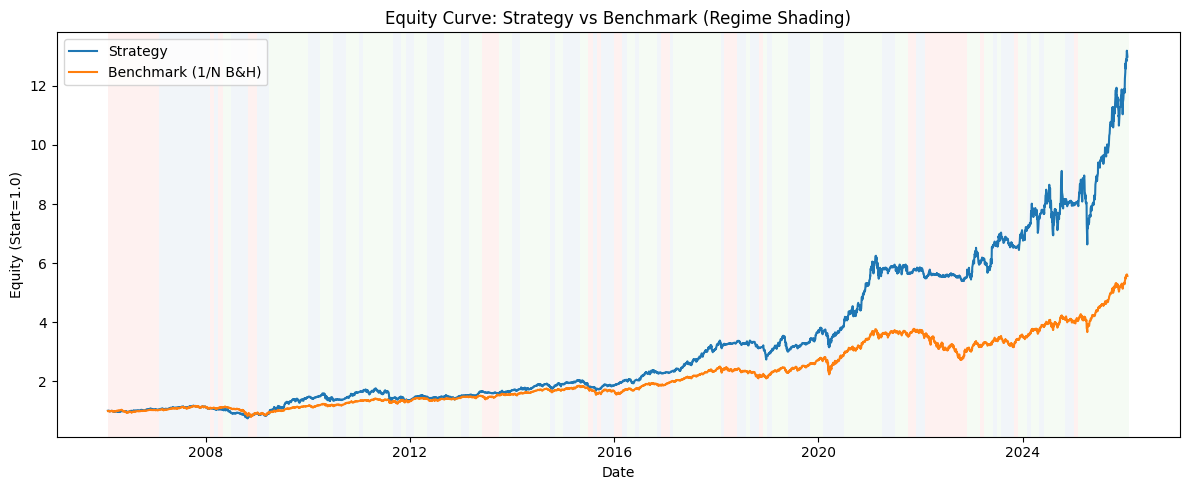

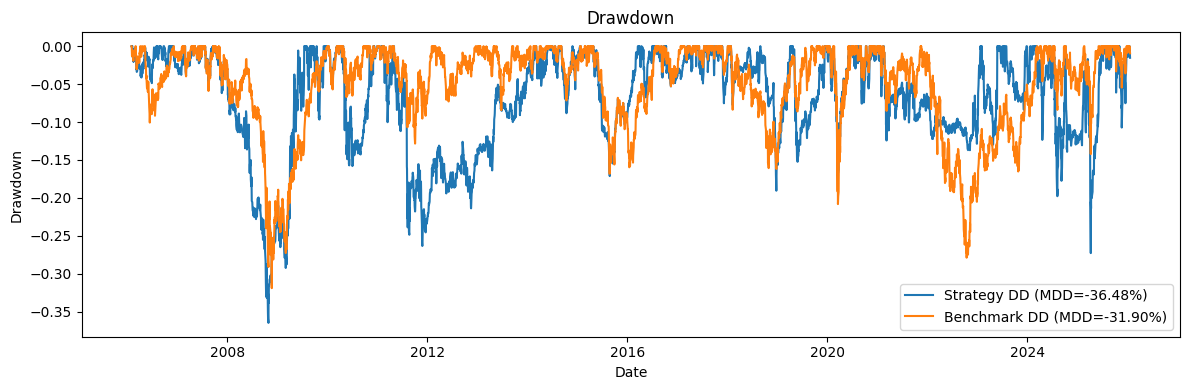

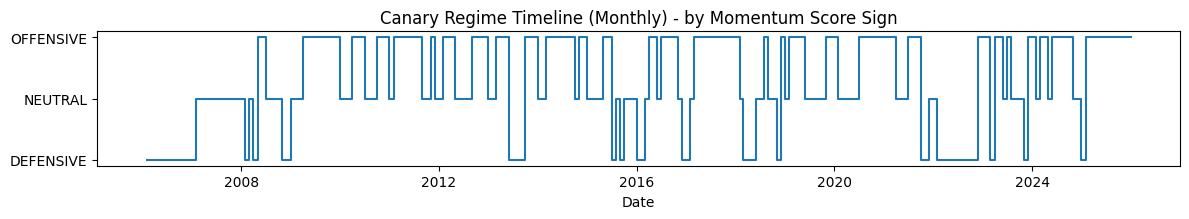


=== Monthly Holdings (Weights) - last 24 months ===


Ticker,BND,CQQQ,EWY,GLD,IEMG,SMH,SOXX,SPY,TLT,UUP,VWO
RebalanceDate,,,,,,,,,,,
2023-03-31,0.0,0.0935,0.1226,0.0000,0.0403,0.3392,0.3075,0.0969,0.0000,0.0000,0.0
2023-05-31,0.0,0.0606,0.0840,0.1195,0.1239,0.0560,0.0563,0.1192,0.1059,0.2747,0.0
2023-06-30,0.0,0.0000,0.0712,0.0000,0.0886,0.3250,0.3197,0.1954,0.0000,0.0000,0.0
2023-07-31,0.0,0.0502,0.0819,0.1466,0.1070,0.0541,0.0538,0.1530,0.1154,0.2379,0.0
2023-08-31,0.0,0.0491,0.0798,0.1635,0.1020,0.0618,0.0586,0.1487,0.1027,0.2338,0.0
2023-10-31,0.0,0.0000,0.0000,0.2725,0.0000,0.0000,0.0000,0.0000,0.1578,0.5697,0.0
2023-11-30,0.0,0.0312,0.1865,0.0000,0.1158,0.2652,0.2504,0.1509,0.0000,0.0000,0.0
2024-01-31,0.0,0.0544,0.0642,0.1460,0.1080,0.0655,0.0598,0.1481,0.0998,0.2542,0.0
2024-02-29,0.0,0.0000,0.1064,0.0000,0.0614,0.3880,0.3110,0.1332,0.0000,0.0000,0.0


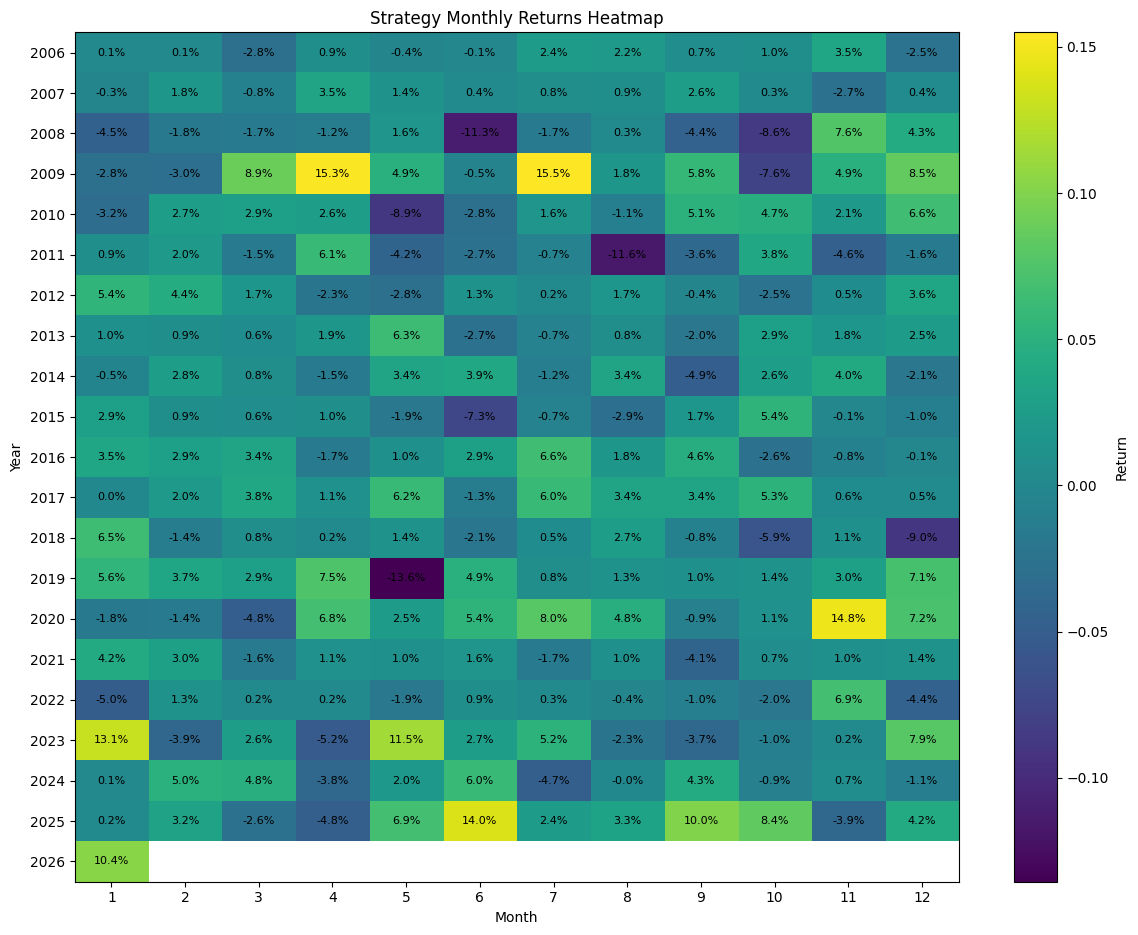

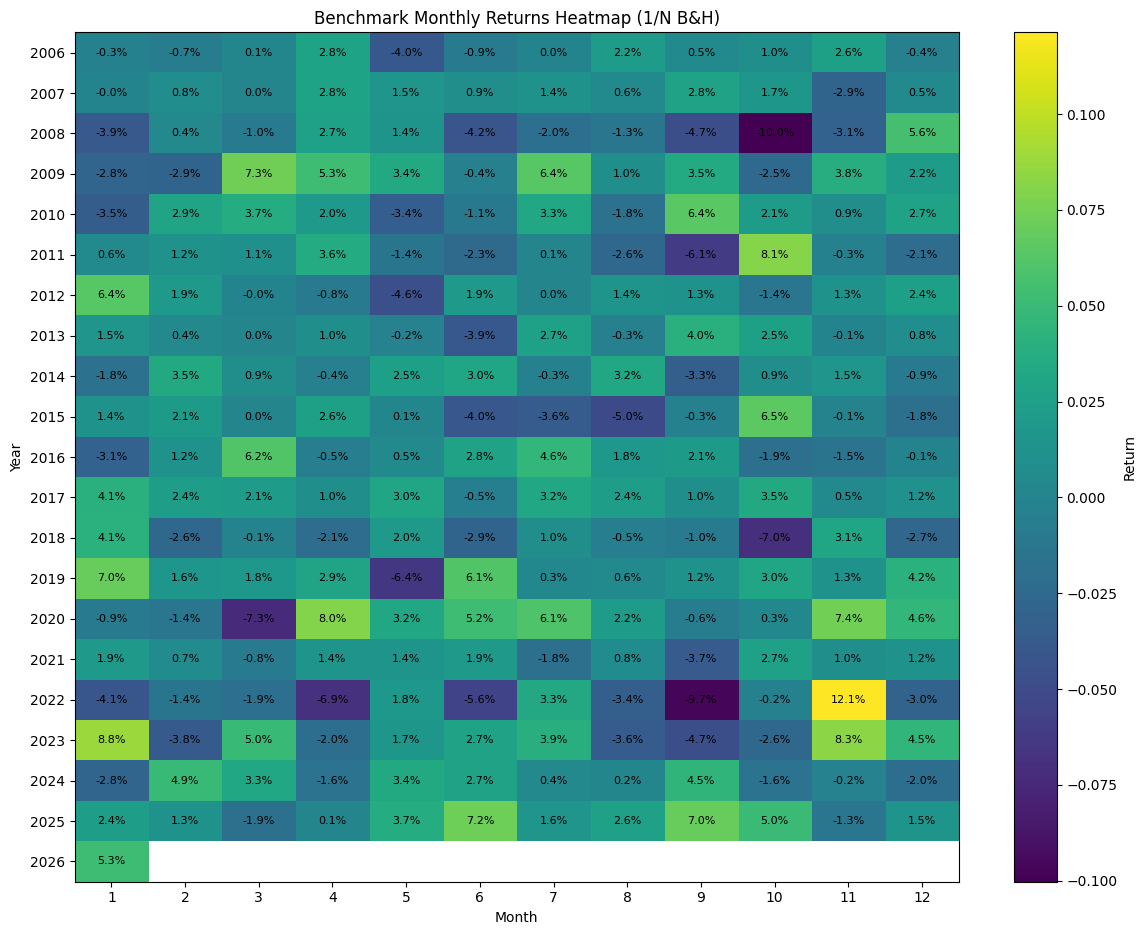


   Performance Tables



,Strategy,Benchmark
CAGR,0.137246,0.089928
Vol,0.171641,0.135201
Sharpe,0.835398,0.704628
Sortino,1.075364,0.969955
MDD,-0.364811,-0.319025
Calmar,0.376213,0.281882
VaR_5%_daily,-0.016383,-0.012853
ES_5%_daily,-0.026150,-0.019348
BestDay,0.093139,0.075555
WorstDay,-0.077587,-0.080842


,Strategy,Benchmark
MonthlyWinRate,0.643154,0.622407
AvgMonthlyRet,0.011596,0.007682
MedianMonthlyRet,0.009092,0.009421
AvgUpMonth,0.034213,0.026961
AvgDownMonth,-0.029166,-0.024097
PayoffRatio,1.173019,1.118870


,Strategy,Benchmark
2006,0.049129,0.028593
2007,0.082651,0.104025
2008,-0.206908,-0.191193
2009,0.618358,0.264267
2010,0.119762,0.145549
2011,-0.172064,-0.009967
2012,0.108820,0.099074
2013,0.138487,0.086004
2014,0.108764,0.088976
2015,-0.020725,-0.026334


,CAGR,Vol,Sharpe,MDD
Regime,,,,
OFFENSIVE,0.234973,0.220313,1.068675,-0.287417
NEUTRAL,0.050214,0.127875,0.447144,-0.287623
DEFENSIVE,0.065545,0.068167,0.965501,-0.068845


,TurnoverStats
AvgMonthlyTurnover,0.732798
MedianMonthlyTurnover,0.943317
MaxMonthlyTurnover,2.000000


In [ ]:
# ============================================================
# Colab ONE-CELL Backtest (DAA Canary Regime: Offensive/Neutral/Defensive)
# + Performance tables ("밑에 성과지표들") + Regime shading
# ============================================================

!pip -q install yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# ----------------------------
# 0) Specs
# ----------------------------
attack_universe = ["SMH", "CQQQ", "SOXX", "SPY", "IEMG", "EWY"]
defense_universe = ["UUP", "GLD", "TLT"]
canary = ["VWO", "BND"]

start = "2006-01-01"
end = None
rebalance_freq = "ME"  # 월말 리밸런싱

MOM_W = {21: 12, 63: 4, 126: 2, 252: 1}  # 1M,3M,6M,12M trading days
rp_lookback = 63
rp_min_obs = 20
fee_per_turnover = 0.0

# ----------------------------
# 1) Helpers
# ----------------------------
def download_close(tickers, start, end):
    data = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        px = data["Close"].copy()
    else:
        if "Close" in data.columns:
            px = data[["Close"]].rename(columns={"Close": tickers[0]})
        else:
            px = data.copy()
    return px.dropna(how="all").sort_index()

def momentum_score(px, asof_dt):
    out = {}
    for t in px.columns:
        s = px[t].dropna()
        if s.empty:
            out[t] = np.nan
            continue
        loc = s.index.searchsorted(asof_dt, side="right") - 1
        if loc < 0:
            out[t] = np.nan
            continue
        score = 0.0
        ok = True
        for lag, w in MOM_W.items():
            j = loc - lag
            if j < 0:
                ok = False
                break
            r = (s.iloc[loc] / s.iloc[j]) - 1.0
            score += w * r
        out[t] = score if ok else np.nan
    return pd.Series(out)

def risk_parity_weights(returns_window):
    if returns_window.shape[0] < rp_min_obs:
        n = returns_window.shape[1]
        return pd.Series(1.0/n, index=returns_window.columns)
    vol = returns_window.std(ddof=0).replace(0, np.nan)
    inv = (1.0 / vol).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    if inv.sum() <= 0:
        n = returns_window.shape[1]
        return pd.Series(1.0/n, index=returns_window.columns)
    return inv / inv.sum()

def max_drawdown(equity):
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min()), dd

def perf_stats(daily_ret):
    daily_ret = daily_ret.dropna()
    if daily_ret.empty:
        return {}
    ann = 252
    eq = (1 + daily_ret).cumprod()
    cagr = eq.iloc[-1] ** (ann / len(daily_ret)) - 1
    vol = daily_ret.std(ddof=0) * np.sqrt(ann)
    sharpe = (daily_ret.mean() * ann) / (daily_ret.std(ddof=0) * np.sqrt(ann) + 1e-12)
    downside = daily_ret[daily_ret < 0]
    sortino = (daily_ret.mean() * ann) / ((downside.std(ddof=0) * np.sqrt(ann)) + 1e-12)
    mdd, _ = max_drawdown(eq)
    calmar = (cagr / abs(mdd)) if mdd < 0 else np.nan

    # VaR/ES (daily, 5%)
    q = 0.05
    var5 = float(daily_ret.quantile(q))
    es5 = float(daily_ret[daily_ret <= var5].mean()) if (daily_ret <= var5).any() else np.nan

    return {
        "CAGR": float(cagr),
        "Vol": float(vol),
        "Sharpe": float(sharpe),
        "Sortino": float(sortino),
        "MDD": float(mdd),
        "Calmar": float(calmar),
        "VaR_5%_daily": float(var5),
        "ES_5%_daily": float(es5),
        "BestDay": float(daily_ret.max()),
        "WorstDay": float(daily_ret.min()),
    }

def monthly_heatmap(monthly_ret, title):
    if monthly_ret.empty:
        print("[WARN] monthly returns empty")
        return
    s = monthly_ret.copy()
    s.index = pd.to_datetime(s.index)
    df = s.to_frame("ret")
    df["Year"] = df.index.year
    df["Month"] = df.index.month
    piv = df.pivot(index="Year", columns="Month", values="ret").sort_index()

    mat = piv.values
    years = piv.index.tolist()
    months = piv.columns.tolist()

    plt.figure(figsize=(12, max(4, 0.45*len(years))))
    plt.imshow(mat, aspect="auto")
    plt.title(title)
    plt.yticks(range(len(years)), years)
    plt.xticks(range(len(months)), [str(m) for m in months])
    plt.xlabel("Month"); plt.ylabel("Year")
    plt.colorbar(label="Return")
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            v = mat[i, j]
            if np.isfinite(v):
                plt.text(j, i, f"{v*100:.1f}%", ha="center", va="center", fontsize=8)
    plt.tight_layout()
    plt.show()

def shade_regimes(ax, regime_monthly):
    cmap = plt.get_cmap("Pastel1")  # 연한 계열
    mapping = {"DEFENSIVE": 0, "NEUTRAL": 1, "OFFENSIVE": 2}
    idx = regime_monthly.index.sort_values()
    for i in range(len(idx)):
        st = idx[i]
        en = idx[i+1] if i < len(idx)-1 else (idx[i] + pd.offsets.MonthEnd(1))
        reg = regime_monthly.loc[st]
        ax.axvspan(st, en, alpha=0.18, color=cmap(mapping[reg]), linewidth=0)

def yearly_returns(daily_ret):
    yr = (1 + daily_ret).resample("YE").prod() - 1
    yr.index = yr.index.year
    return yr

def monthly_summary(monthly_ret):
    if monthly_ret.empty:
        return pd.Series(dtype=float)
    win_rate = float((monthly_ret > 0).mean())
    avg = float(monthly_ret.mean())
    med = float(monthly_ret.median())
    pos = monthly_ret[monthly_ret > 0]
    neg = monthly_ret[monthly_ret < 0]
    gain = float(pos.mean()) if not pos.empty else np.nan
    loss = float(neg.mean()) if not neg.empty else np.nan
    payoff = float(gain / abs(loss)) if (not np.isnan(gain) and not np.isnan(loss) and loss != 0) else np.nan
    return pd.Series({
        "MonthlyWinRate": win_rate,
        "AvgMonthlyRet": avg,
        "MedianMonthlyRet": med,
        "AvgUpMonth": gain,
        "AvgDownMonth": loss,
        "PayoffRatio": payoff,
    })

def regime_performance(daily_ret, daily_regime):
    """
    daily_regime: Series index=daily dates, values regime label
    """
    rows = []
    for reg in ["OFFENSIVE", "NEUTRAL", "DEFENSIVE"]:
        dr = daily_ret[daily_regime == reg].dropna()
        if dr.empty:
            rows.append([reg, np.nan, np.nan, np.nan, np.nan])
            continue
        st = perf_stats(dr)
        rows.append([reg, st["CAGR"], st["Vol"], st["Sharpe"], st["MDD"]])
    return pd.DataFrame(rows, columns=["Regime", "CAGR", "Vol", "Sharpe", "MDD"]).set_index("Regime")

# ----------------------------
# 2) Data
# ----------------------------
all_universe = list(dict.fromkeys(attack_universe + defense_universe + canary))
px = download_close(all_universe, start, end)
ret = px.pct_change().dropna(how="all")

month_ends = px.resample(rebalance_freq).last().index
month_ends = month_ends[month_ends.isin(px.index)]

# ----------------------------
# 3) Regime (by canary momentum score sign)
# ----------------------------
def get_regime(asof_dt):
    ms = momentum_score(px[canary], asof_dt)
    pos = (ms >= 0).fillna(False).sum()
    if pos >= 2:
        return "OFFENSIVE"
    elif pos == 1:
        return "NEUTRAL"
    else:
        return "DEFENSIVE"

# ----------------------------
# 4) Monthly weights
# ----------------------------
w_list, reg_list, turn_list = [], [], []
prev_w = pd.Series(0.0, index=ret.columns)

for dt in month_ends:
    regime = get_regime(dt)
    reg_list.append((dt, regime))

    w = pd.Series(0.0, index=ret.columns)

    if regime == "OFFENSIVE":
        mom = momentum_score(px[attack_universe], dt).reindex(attack_universe)
        mom_pos = mom.clip(lower=0.0).fillna(0.0)
        if mom_pos.sum() <= 0:
            win = ret.loc[:dt, defense_universe].tail(rp_lookback)
            wd = risk_parity_weights(win)
            w.loc[defense_universe] = wd
        else:
            w.loc[attack_universe] = mom_pos / mom_pos.sum()

    elif regime == "NEUTRAL":
        win_a = ret.loc[:dt, attack_universe].tail(rp_lookback)
        win_d = ret.loc[:dt, defense_universe].tail(rp_lookback)
        wa = risk_parity_weights(win_a)
        wd = risk_parity_weights(win_d)
        w.loc[attack_universe] = 0.5 * wa
        w.loc[defense_universe] = 0.5 * wd

    else:  # DEFENSIVE
        win_d = ret.loc[:dt, defense_universe].tail(rp_lookback)
        wd = risk_parity_weights(win_d)
        w.loc[defense_universe] = wd

    w = w.fillna(0.0)
    if w.sum() > 0:
        w = w / w.sum()

    turnover = (w - prev_w).abs().sum()
    prev_w = w.copy()

    w_list.append((dt, w))
    turn_list.append((dt, turnover))

w_df = pd.DataFrame({dt: w for dt, w in w_list}).T
w_df.index.name = "RebalanceDate"

regime_m = pd.Series({dt: rg for dt, rg in reg_list}, name="Regime")
turnover_m = pd.Series({dt: tv for dt, tv in turn_list}, name="Turnover")

# ----------------------------
# 5) Daily backtest
# ----------------------------
reb_idx = w_df.index

def asof_w(date):
    loc = reb_idx.searchsorted(date, side="right") - 1
    if loc < 0:
        return None
    return w_df.iloc[loc]

# Benchmark: ALL universe 1/N buy & hold
bm_assets = list(dict.fromkeys(attack_universe + defense_universe + canary))
bm_assets = [a for a in bm_assets if a in ret.columns]
bm_w = pd.Series(1.0/len(bm_assets), index=bm_assets)

port_ret, bench_ret = [], []

for dt in ret.index:
    w_today = asof_w(dt)
    if w_today is None:
        continue
    r = ret.loc[dt].fillna(0.0)

    pr = float((w_today.reindex(ret.columns).fillna(0.0) * r).sum())
    if dt in w_df.index:
        pr -= fee_per_turnover * float(turnover_m.get(dt, 0.0))

    br = float((bm_w * r.reindex(bm_w.index).fillna(0.0)).sum())

    port_ret.append((dt, pr))
    bench_ret.append((dt, br))

port_ret = pd.Series(dict(port_ret), name="Strategy")
bench_ret = pd.Series(dict(bench_ret), name="Benchmark")

port_eq = (1 + port_ret).cumprod()
bench_eq = (1 + bench_ret).cumprod()

port_month = (1 + port_ret).resample("ME").prod() - 1
bench_month = (1 + bench_ret).resample("ME").prod() - 1

# daily regime series (asof monthly)
daily_regime = pd.Series(index=port_ret.index, dtype="object")
for dt in port_ret.index:
    loc = regime_m.index.searchsorted(dt, side="right") - 1
    if loc >= 0:
        daily_regime.loc[dt] = regime_m.iloc[loc]

# ----------------------------
# 6) Plots
# ----------------------------
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(port_eq.index, port_eq.values, label="Strategy")
ax.plot(bench_eq.index, bench_eq.values, label="Benchmark (1/N B&H)")
shade_regimes(ax, regime_m)
ax.set_title("Equity Curve: Strategy vs Benchmark (Regime Shading)")
ax.set_xlabel("Date"); ax.set_ylabel("Equity (Start=1.0)")
ax.legend()
plt.tight_layout()
plt.show()

mdd_s, dd_s = max_drawdown(port_eq)
mdd_b, dd_b = max_drawdown(bench_eq)

plt.figure(figsize=(12,4))
plt.plot(dd_s.index, dd_s.values, label=f"Strategy DD (MDD={mdd_s:.2%})")
plt.plot(dd_b.index, dd_b.values, label=f"Benchmark DD (MDD={mdd_b:.2%})")
plt.title("Drawdown")
plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()

# regime timeline
reg_map = {"DEFENSIVE": 0, "NEUTRAL": 1, "OFFENSIVE": 2}
plt.figure(figsize=(12,2.3))
plt.plot(regime_m.index, regime_m.map(reg_map).values, drawstyle="steps-post")
plt.yticks([0,1,2], ["DEFENSIVE","NEUTRAL","OFFENSIVE"])
plt.title("Canary Regime Timeline (Monthly) - by Momentum Score Sign")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

# holdings
print("\n=== Monthly Holdings (Weights) - last 24 months ===")
display(w_df.tail(24).round(4))

# monthly heatmaps
monthly_heatmap(port_month, "Strategy Monthly Returns Heatmap")
monthly_heatmap(bench_month, "Benchmark Monthly Returns Heatmap (1/N B&H)")

# ----------------------------
# 7) "밑에 성과지표들" (tables)
# ----------------------------
print("\n====================")
print("   Performance Tables")
print("====================\n")

# Core stats
stats_table = pd.DataFrame({
    "Strategy": perf_stats(port_ret),
    "Benchmark": perf_stats(bench_ret)
})
display(stats_table)

# Monthly summary stats
ms_table = pd.DataFrame({
    "Strategy": monthly_summary(port_month),
    "Benchmark": monthly_summary(bench_month)
})
display(ms_table)

# Yearly returns table
yr_table = pd.DataFrame({
    "Strategy": yearly_returns(port_ret),
    "Benchmark": yearly_returns(bench_ret)
}).sort_index()
display(yr_table)

# Regime performance (strategy only)
reg_perf = regime_performance(port_ret, daily_regime)
display(reg_perf)

# Turnover summary
turnover_summary = pd.Series({
    "AvgMonthlyTurnover": float(turnover_m.mean()),
    "MedianMonthlyTurnover": float(turnover_m.median()),
    "MaxMonthlyTurnover": float(turnover_m.max()),
})
display(turnover_summary.to_frame("TurnoverStats"))


=== Performance Summary (Strategy vs Benchmark) ===


,Strategy,Benchmark
CAGR,0.137246,0.089928
Vol(ann),0.171641,0.135201
Sharpe,0.835398,0.704628
Sortino,1.075364,0.969955
MDD,-0.364811,-0.319025
Calmar,0.376213,0.281882
HitRate(daily),0.538018,0.541600
BestDay,0.093139,0.075555
WorstDay,-0.077587,-0.080842
TotalReturn,11.988104,4.566453



=== Monthly Stats (Strategy vs Benchmark) ===


,Strategy,Benchmark
WinRate(monthly),0.643154,0.622407
AvgMonthly,0.011596,0.007682
MedianMonthly,0.009092,0.009421
StdMonthly,0.042732,0.032724
PayoffRatio,1.173019,1.118870
BestMonth,0.154949,0.121330
WorstMonth,-0.135526,-0.100281



=== Yearly Returns (Strategy vs Benchmark) ===


,Strategy,Benchmark
2006,0.049129,0.028593
2007,0.082651,0.104025
2008,-0.206908,-0.191193
2009,0.618358,0.264267
2010,0.119762,0.145549
2011,-0.172064,-0.009967
2012,0.108820,0.099074
2013,0.138487,0.086004
2014,0.108764,0.088976
2015,-0.020725,-0.026334


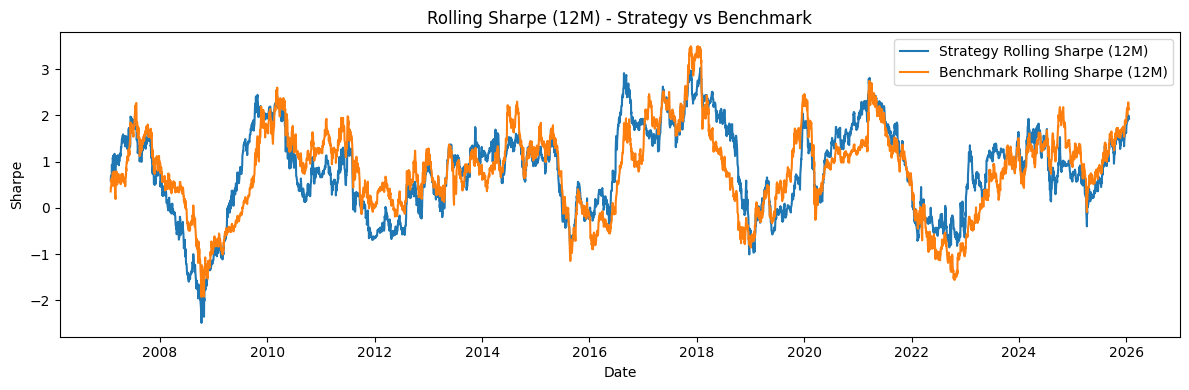

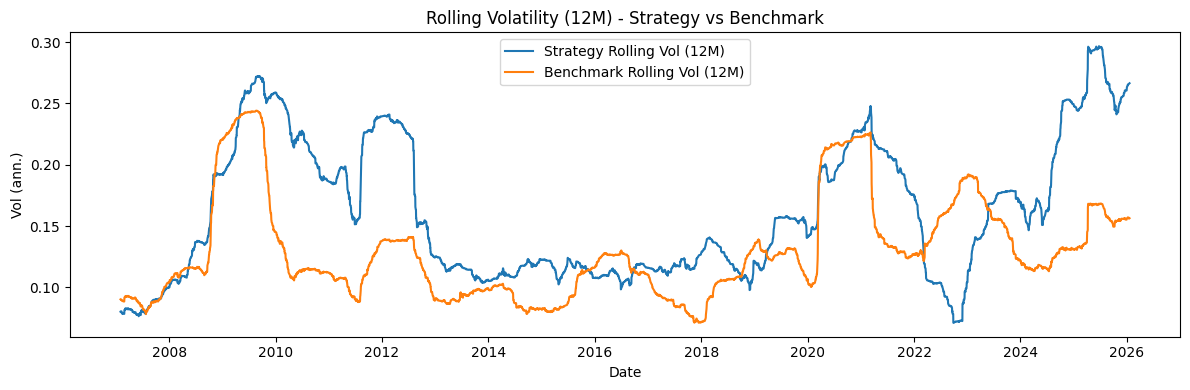

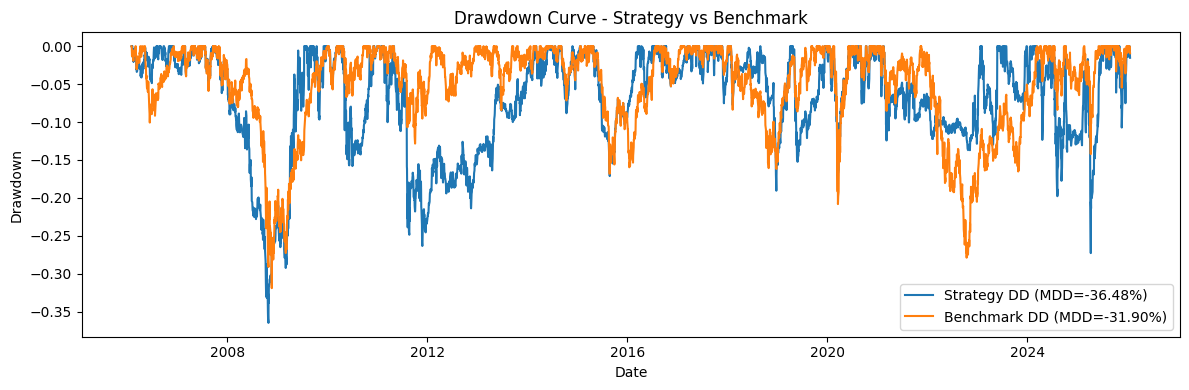

In [ ]:
# ============================================================
# [추가 셀] 성과지표(Sharpe/MDD 등) + Benchmark 비교
#  - 핵심 요약 테이블
#  - 롤링(12M) Sharpe / Vol
#  - 연도별 성과 비교
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _max_drawdown_from_returns(daily_ret: pd.Series):
    eq = (1 + daily_ret.dropna()).cumprod()
    peak = eq.cummax()
    dd = eq / peak - 1.0
    return float(dd.min()), dd, eq

def _perf_table(daily_ret: pd.Series, name=""):
    daily_ret = daily_ret.dropna()
    ann = 252

    mdd, dd, eq = _max_drawdown_from_returns(daily_ret)

    cagr = eq.iloc[-1] ** (ann / len(daily_ret)) - 1
    vol = daily_ret.std(ddof=0) * np.sqrt(ann)
    sharpe = (daily_ret.mean() * ann) / (daily_ret.std(ddof=0) * np.sqrt(ann) + 1e-12)

    downside = daily_ret[daily_ret < 0]
    sortino = (daily_ret.mean() * ann) / (downside.std(ddof=0) * np.sqrt(ann) + 1e-12)

    calmar = (cagr / abs(mdd)) if mdd < 0 else np.nan

    hit = float((daily_ret > 0).mean())
    best = float(daily_ret.max())
    worst = float(daily_ret.min())

    return pd.Series({
        "CAGR": float(cagr),
        "Vol(ann)": float(vol),
        "Sharpe": float(sharpe),
        "Sortino": float(sortino),
        "MDD": float(mdd),
        "Calmar": float(calmar),
        "HitRate(daily)": float(hit),
        "BestDay": float(best),
        "WorstDay": float(worst),
        "TotalReturn": float(eq.iloc[-1] - 1.0),
        "FinalEquity": float(eq.iloc[-1]),
    }, name=name)

# 1) 핵심 성과지표 테이블 (전략 vs 벤치마크)
perf = pd.concat([
    _perf_table(port_ret, "Strategy"),
    _perf_table(bench_ret, "Benchmark"),
], axis=1)

print("=== Performance Summary (Strategy vs Benchmark) ===")
display(perf)

# 2) 월별 성과 (추가 비교)
port_m = (1 + port_ret).resample("ME").prod() - 1
bench_m = (1 + bench_ret).resample("ME").prod() - 1

def _monthly_stats(m: pd.Series, name=""):
    m = m.dropna()
    win = float((m > 0).mean())
    avg = float(m.mean())
    med = float(m.median())
    std = float(m.std(ddof=0))
    pos = m[m > 0]
    neg = m[m < 0]
    payoff = float(pos.mean() / abs(neg.mean())) if (not pos.empty and not neg.empty and neg.mean() != 0) else np.nan
    return pd.Series({
        "WinRate(monthly)": win,
        "AvgMonthly": avg,
        "MedianMonthly": med,
        "StdMonthly": std,
        "PayoffRatio": payoff,
        "BestMonth": float(m.max()) if not m.empty else np.nan,
        "WorstMonth": float(m.min()) if not m.empty else np.nan,
    }, name=name)

monthly_comp = pd.concat([
    _monthly_stats(port_m, "Strategy"),
    _monthly_stats(bench_m, "Benchmark"),
], axis=1)

print("\n=== Monthly Stats (Strategy vs Benchmark) ===")
display(monthly_comp)

# 3) 연도별 수익률 테이블 (전략 vs 벤치마크)
yr = pd.DataFrame({
    "Strategy": (1 + port_ret).resample("YE").prod() - 1,
    "Benchmark": (1 + bench_ret).resample("YE").prod() - 1,
})
yr.index = yr.index.year
print("\n=== Yearly Returns (Strategy vs Benchmark) ===")
display(yr)

# 4) Rolling 12M Sharpe / Vol (둘 다)
window = 252  # 12개월(거래일 기준)
def _rolling_sharpe(daily_ret: pd.Series, w=252):
    mu = daily_ret.rolling(w).mean() * 252
    sig = daily_ret.rolling(w).std(ddof=0) * np.sqrt(252)
    return mu / (sig + 1e-12)

def _rolling_vol(daily_ret: pd.Series, w=252):
    return daily_ret.rolling(w).std(ddof=0) * np.sqrt(252)

rs_s = _rolling_sharpe(port_ret, window)
rs_b = _rolling_sharpe(bench_ret, window)

rv_s = _rolling_vol(port_ret, window)
rv_b = _rolling_vol(bench_ret, window)

plt.figure(figsize=(12,4))
plt.plot(rs_s.index, rs_s.values, label="Strategy Rolling Sharpe (12M)")
plt.plot(rs_b.index, rs_b.values, label="Benchmark Rolling Sharpe (12M)")
plt.title("Rolling Sharpe (12M) - Strategy vs Benchmark")
plt.xlabel("Date"); plt.ylabel("Sharpe")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(rv_s.index, rv_s.values, label="Strategy Rolling Vol (12M)")
plt.plot(rv_b.index, rv_b.values, label="Benchmark Rolling Vol (12M)")
plt.title("Rolling Volatility (12M) - Strategy vs Benchmark")
plt.xlabel("Date"); plt.ylabel("Vol (ann.)")
plt.legend()
plt.tight_layout()
plt.show()

# 5) MDD 곡선 비교(이미 위에서 DD를 그렸어도, 표준화해서 다시 보여드림)
mdd_s, dd_s, eq_s = _max_drawdown_from_returns(port_ret)
mdd_b, dd_b, eq_b = _max_drawdown_from_returns(bench_ret)

plt.figure(figsize=(12,4))
plt.plot(dd_s.index, dd_s.values, label=f"Strategy DD (MDD={mdd_s:.2%})")
plt.plot(dd_b.index, dd_b.values, label=f"Benchmark DD (MDD={mdd_b:.2%})")
plt.title("Drawdown Curve - Strategy vs Benchmark")
plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()


=== Params ===
B = 1.5 * long_std(d) | EMA=255 | K=6 months | Amax=0.7

=== Performance (Daily) ===
Strategy : {'CAGR': 0.10213333259602075, 'Vol': 0.11094098735197241, 'Sharpe': 0.9322036621215835, 'MDD': -0.3275507899131611}
Benchmark: {'CAGR': 0.09118755471181306, 'Vol': 0.13525865166450496, 'Sharpe': 0.7129301280713242, 'MDD': -0.3190254148912217}


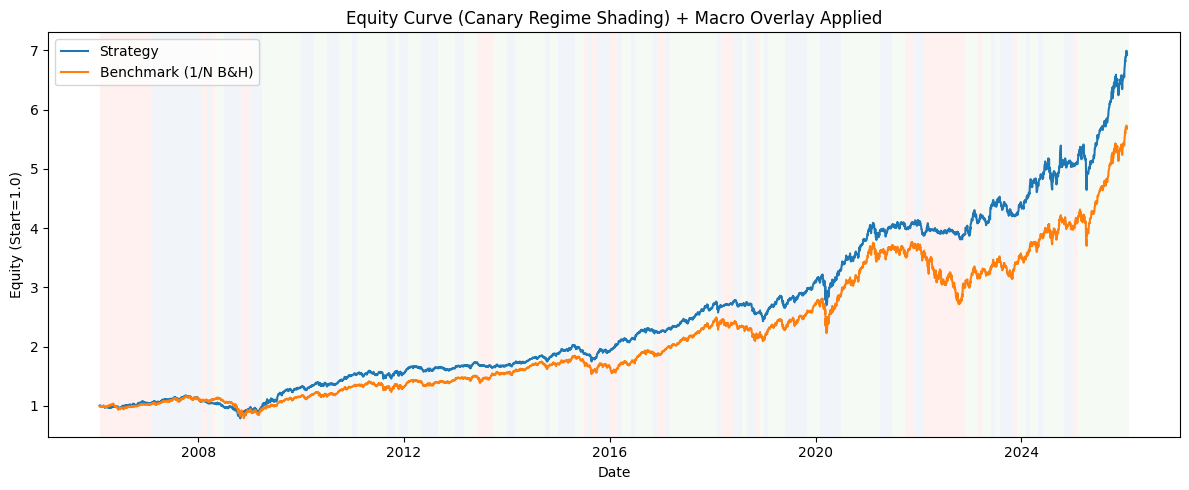

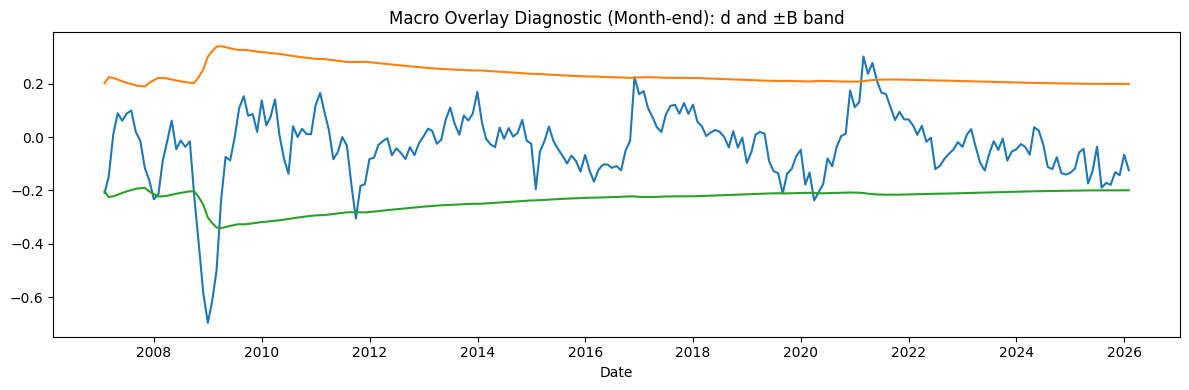


=== Recent Monthly Weights (last 12) ===


Ticker,BND,CQQQ,EWY,GLD,IEMG,SMH,SOXX,SPY,TLT,UUP,VWO
RebalanceDate,,,,,,,,,,,
2024-09-30,0.0,0.2805,0.0000,0.1071,0.0761,0.0529,0.0298,0.0608,0.1186,0.2743,0.0
2024-10-31,0.0,0.0402,0.0796,0.1112,0.1161,0.0566,0.0555,0.1521,0.1230,0.2658,0.0
2024-12-31,0.0,0.0000,0.0000,0.2232,0.0000,0.0000,0.0000,0.0000,0.2464,0.5304,0.0
2025-01-31,0.0,0.2550,0.0000,0.1157,0.0304,0.0089,0.0000,0.2057,0.1355,0.2489,0.0
2025-02-28,0.0,0.4466,0.0000,0.1226,0.0328,0.0000,0.0000,0.0206,0.1290,0.2484,0.0
2025-03-31,0.0,0.4060,0.0000,0.1318,0.0940,0.0000,0.0000,0.0000,0.1359,0.2323,0.0
2025-04-30,0.0,0.0000,0.3373,0.1146,0.1627,0.0000,0.0000,0.0000,0.1443,0.2411,0.0
2025-06-30,0.0,0.0413,0.1407,0.0974,0.0574,0.1139,0.1021,0.0446,0.1577,0.2449,0.0
2025-07-31,0.0,0.0898,0.1037,0.0960,0.0493,0.1252,0.0782,0.0538,0.1590,0.2450,0.0



=== MacroState counts (monthly) ===


,count
MacroState,
-1,6
0,223



=== Canary regime counts (monthly) ===


,count
CanaryRegime,
OFFENSIVE,79
NEUTRAL,58
DEFENSIVE,33


In [ ]:
!pip -q install yfinance

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# =========================
# 0) Universe / Params
# =========================
attack_universe = ["SMH", "CQQQ", "SOXX", "SPY", "IEMG", "EWY"]
defense_universe = ["UUP", "GLD", "TLT"]
canary = ["VWO", "BND"]

# Copper/Gold proxy (Yahoo)
# - Copper futures: HG=F
# - Gold futures  : GC=F
copper_ticker = "HG=F"
gold_ticker   = "GC=F"

start = "2006-01-01"
end = None
rebalance_freq = "ME"  # 월말 리밸런싱

# Momentum score weights (given)
MOM_W = {21: 12, 63: 4, 126: 2, 252: 1}

# RP
rp_lookback = 63
rp_min_obs = 20

# Macro overlay params (UPDATED)
EMA_N = 255
B_MULT = 1.5
K_MONTHS = 6
AMAX = 0.7

# Trading cost (optional; 0 default)
fee_per_turnover = 0.0

# =========================
# 1) Helpers
# =========================
def download_close(tickers, start, end):
    data = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=False)
    if isinstance(data.columns, pd.MultiIndex):
        px = data["Close"].copy()
    else:
        px = data.copy()
        if "Close" in px.columns:
            # 단일 티커 예외
            if len(tickers) == 1:
                px = px[["Close"]].rename(columns={"Close": tickers[0]})
            else:
                px = px["Close"].to_frame()
    return px.dropna(how="all").sort_index()

def momentum_score(px, asof_dt):
    out = {}
    for t in px.columns:
        s = px[t].dropna()
        if s.empty:
            out[t] = np.nan
            continue
        loc = s.index.searchsorted(asof_dt, side="right") - 1
        if loc < 0:
            out[t] = np.nan
            continue
        score = 0.0
        ok = True
        for lag, w in MOM_W.items():
            j = loc - lag
            if j < 0:
                ok = False
                break
            r = (s.iloc[loc] / s.iloc[j]) - 1.0
            score += w * r
        out[t] = score if ok else np.nan
    return pd.Series(out)

def risk_parity_weights(returns_window):
    if returns_window.shape[0] < rp_min_obs:
        n = returns_window.shape[1]
        return pd.Series(1.0/n, index=returns_window.columns)
    vol = returns_window.std(ddof=0).replace(0, np.nan)
    inv = (1.0 / vol).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    if inv.sum() <= 0:
        n = returns_window.shape[1]
        return pd.Series(1.0/n, index=returns_window.columns)
    return inv / inv.sum()

def max_drawdown(equity):
    peak = equity.cummax()
    dd = equity / peak - 1.0
    return float(dd.min()), dd

def perf_stats(daily_ret):
    daily_ret = daily_ret.dropna()
    if daily_ret.empty:
        return {}
    ann = 252
    eq = (1 + daily_ret).cumprod()
    cagr = eq.iloc[-1] ** (ann / len(daily_ret)) - 1
    vol = daily_ret.std(ddof=0) * np.sqrt(ann)
    sharpe = (daily_ret.mean() * ann) / (daily_ret.std(ddof=0) * np.sqrt(ann) + 1e-12)
    mdd, _ = max_drawdown(eq)
    return {"CAGR": float(cagr), "Vol": float(vol), "Sharpe": float(sharpe), "MDD": float(mdd)}

def shade_regimes(ax, regime_monthly):
    # 기본 colormap으로 연하게만 처리(직접 색상 지정 없음)
    cmap = plt.get_cmap("Pastel1")
    mapping = {"DEFENSIVE": 0, "NEUTRAL": 1, "OFFENSIVE": 2}
    idx = regime_monthly.index.sort_values()
    for i in range(len(idx)):
        st = idx[i]
        en = idx[i+1] if i < len(idx)-1 else (idx[i] + pd.offsets.MonthEnd(1))
        reg = regime_monthly.loc[st]
        ax.axvspan(st, en, alpha=0.18, color=cmap(mapping[reg]), linewidth=0)

# =========================
# 2) Download data
# =========================
all_universe = list(dict.fromkeys(attack_universe + defense_universe + canary))
px = download_close(all_universe + [copper_ticker, gold_ticker], start, end)

# 분리
px_assets = px[[c for c in px.columns if c in all_universe]].copy()
px_cu = px[[copper_ticker]].rename(columns={copper_ticker: "COPPER"}).copy()
px_au = px[[gold_ticker]].rename(columns={gold_ticker: "GOLD"}).copy()

# 동일 날짜로 정렬
px_macro = px_cu.join(px_au, how="inner").dropna()
px_assets = px_assets.join(px_macro[["COPPER","GOLD"]], how="inner")
px_assets = px_assets.drop(columns=["COPPER","GOLD"])

ret = px_assets.pct_change(fill_method=None).dropna(how="all")

# 리밸런싱 날짜(월말)
month_ends = px_assets.resample(rebalance_freq).last().index
month_ends = month_ends[month_ends.isin(px_assets.index)]

# =========================
# 3) Canary regime (by canary momentum score sign)
# =========================
def get_canary_regime(asof_dt):
    ms = momentum_score(px_assets[canary], asof_dt)
    pos = (ms >= 0).fillna(False).sum()
    if pos >= 2:
        return "OFFENSIVE"
    elif pos == 1:
        return "NEUTRAL"
    else:
        return "DEFENSIVE"

# =========================
# 4) MacroState from log(Cu/Au) with EMA255 + B(1.5*long_std) + K(6m confirm)
# =========================
# daily macro series
x = np.log(px_macro["COPPER"] / px_macro["GOLD"]).rename("x_log_CuAu")
m = x.ewm(span=EMA_N, adjust=False).mean().rename("ema255")
d = (x - m).rename("d")

# "장기 표준편차"는 expanding std(누적)로 구현: 거시답게 천천히 변화
d_std_long = d.expanding(min_periods=EMA_N).std(ddof=0).rename("d_std_long")
B = (B_MULT * d_std_long).rename("B")

macro_df = pd.concat([x, m, d, d_std_long, B], axis=1).dropna()

# month-end macro snapshot
macro_m = macro_df.resample("ME").last().dropna()

# raw state at month-end
def raw_macro_state(row):
    if row["d"] > row["B"]:
        return 1
    elif row["d"] < -row["B"]:
        return -1
    else:
        return 0

raw_state = macro_m.apply(raw_macro_state, axis=1).rename("raw")

# confirm K months: raw가 K개월 연속 동일할 때만 상태 업데이트
macro_state = []
cur = 0  # 초기 상태는 0(보수적)
streak = 0
prev_raw = None

for dt, rv in raw_state.items():
    if prev_raw is None or rv != prev_raw:
        streak = 1
        prev_raw = rv
    else:
        streak += 1

    # K개월 연속이면 업데이트(단, raw=0도 업데이트 허용: 전환/혼재를 명시)
    if streak >= K_MONTHS:
        cur = int(rv)

    macro_state.append((dt, cur))

macro_state = pd.Series(dict(macro_state), name="MacroState")  # -1/0/+1

# =========================
# 5) Monthly weights with macro overlay (NO decision power, only adjustment)
# =========================
w_list = []
reg_list = []
turn_list = []
prev_w = pd.Series(0.0, index=ret.columns)

for dt in month_ends:
    can_reg = get_canary_regime(dt)
    reg_list.append((dt, can_reg))

    # 기본 구성요소 준비
    # - 공격 모멘텀 전체 비중
    mom = momentum_score(px_assets[attack_universe], dt).reindex(attack_universe)
    mom_pos = mom.clip(lower=0.0).fillna(0.0)
    if mom_pos.sum() <= 0:
        w_off = pd.Series(0.0, index=ret.columns)
    else:
        w_off = pd.Series(0.0, index=ret.columns)
        w_off.loc[attack_universe] = mom_pos / mom_pos.sum()

    # - 수비 RP
    win_d = ret.loc[:dt, defense_universe].tail(rp_lookback)
    w_def = pd.Series(0.0, index=ret.columns)
    w_def.loc[defense_universe] = risk_parity_weights(win_d)

    # - 중립(기본): 공격RP 50% + 수비RP 50%
    win_a = ret.loc[:dt, attack_universe].tail(rp_lookback)
    w_off_rp = pd.Series(0.0, index=ret.columns)
    w_off_rp.loc[attack_universe] = risk_parity_weights(win_a)
    w_neu = 0.5 * w_off_rp + 0.5 * w_def

    # macro state asof dt (month-end series -> asof)
    locm = macro_state.index.searchsorted(dt, side="right") - 1
    ms = int(macro_state.iloc[locm]) if locm >= 0 else 0

    w = pd.Series(0.0, index=ret.columns)

    if can_reg == "OFFENSIVE":
        # 거시 보정기: 결정권 없이, 강도/혼합만 조절
        if ms == 1:
            # 거시 순풍: 공격 그대로
            w = w_off.copy()
        elif ms == 0:
            # 거시 혼재: 공격/수비 1:1 혼합(추가 파라미터 없이 고정)
            w = 0.5 * w_off + 0.5 * w_def
        else:  # ms == -1
            # 거시 역풍: 공격 강도 상한(Amax)로 제한
            w = AMAX * w_off + (1 - AMAX) * w_def

        # 공격 모멘텀이 전부 음수로 w_off가 0이면, 자동으로 수비 쪽이 살아남습니다.
        if w.sum() <= 0:
            w = w_def.copy()

    elif can_reg == "NEUTRAL":
        # 중립은 안전지대: 거시는 레짐을 바꾸지 않습니다(의도 반영)
        w = w_neu.copy()

    else:  # DEFENSIVE
        w = w_def.copy()

    # 정규화
    w = w.fillna(0.0)
    if w.sum() > 0:
        w = w / w.sum()

    # turnover
    turnover = (w - prev_w).abs().sum()
    prev_w = w.copy()

    w_list.append((dt, w))
    turn_list.append((dt, turnover))

w_df = pd.DataFrame({dt: w for dt, w in w_list}).T
w_df.index.name = "RebalanceDate"
regime_s = pd.Series({dt: rg for dt, rg in reg_list}, name="CanaryRegime")
turnover_s = pd.Series({dt: tv for dt, tv in turn_list}, name="Turnover")

# =========================
# 6) Daily backtest (piecewise constant weights)
# =========================
reb_idx = w_df.index

def asof_w(date):
    loc = reb_idx.searchsorted(date, side="right") - 1
    if loc < 0:
        return None
    return w_df.iloc[loc]

# Benchmark: ALL universe 1/N buy&hold (공격+수비+카나리아)
bm_assets = list(dict.fromkeys(attack_universe + defense_universe + canary))
bm_assets = [a for a in bm_assets if a in ret.columns]
bm_w = pd.Series(1.0/len(bm_assets), index=bm_assets)

port_ret = []
bench_ret = []

for dt in ret.index:
    w_today = asof_w(dt)
    if w_today is None:
        continue
    r = ret.loc[dt].fillna(0.0)

    pr = float((w_today.reindex(ret.columns).fillna(0.0) * r).sum())
    if dt in w_df.index:
        pr -= fee_per_turnover * float(turnover_s.get(dt, 0.0))
    br = float((bm_w * r.reindex(bm_w.index).fillna(0.0)).sum())

    port_ret.append((dt, pr))
    bench_ret.append((dt, br))

port_ret = pd.Series(dict(port_ret), name="Strategy")
bench_ret = pd.Series(dict(bench_ret), name="Benchmark")

port_eq = (1 + port_ret).cumprod()
bench_eq = (1 + bench_ret).cumprod()

# =========================
# 7) Output
# =========================
print("=== Params ===")
print(f"B = 1.5 * long_std(d) | EMA={EMA_N} | K={K_MONTHS} months | Amax={AMAX}")
print("\n=== Performance (Daily) ===")
print("Strategy :", perf_stats(port_ret))
print("Benchmark:", perf_stats(bench_ret))

# Equity with canary regime shading
fig, ax = plt.subplots(figsize=(12,5))
ax.plot(port_eq.index, port_eq.values, label="Strategy")
ax.plot(bench_eq.index, bench_eq.values, label="Benchmark (1/N B&H)")
shade_regimes(ax, regime_s)
ax.set_title("Equity Curve (Canary Regime Shading) + Macro Overlay Applied")
ax.set_xlabel("Date")
ax.set_ylabel("Equity (Start=1.0)")
ax.legend()
plt.tight_layout()
plt.show()

# Macro diagnostic plot (optional, but helpful): d and band at month-end
macro_plot = pd.DataFrame({
    "d": macro_m["d"],
    "B": macro_m["B"],
    "MacroState": macro_state.reindex(macro_m.index),
}).dropna()

plt.figure(figsize=(12,4))
plt.plot(macro_plot.index, macro_plot["d"].values, label="d = log(Cu/Au) - EMA255")
plt.plot(macro_plot.index, macro_plot["B"].values, label="Band +B")
plt.plot(macro_plot.index, (-macro_plot["B"]).values, label="Band -B")
plt.title("Macro Overlay Diagnostic (Month-end): d and ±B band")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

print("\n=== Recent Monthly Weights (last 12) ===")
display(w_df.tail(12).round(4))

print("\n=== MacroState counts (monthly) ===")
display(macro_state.value_counts().sort_index().to_frame("count"))

print("\n=== Canary regime counts (monthly) ===")
display(regime_s.value_counts().to_frame("count"))


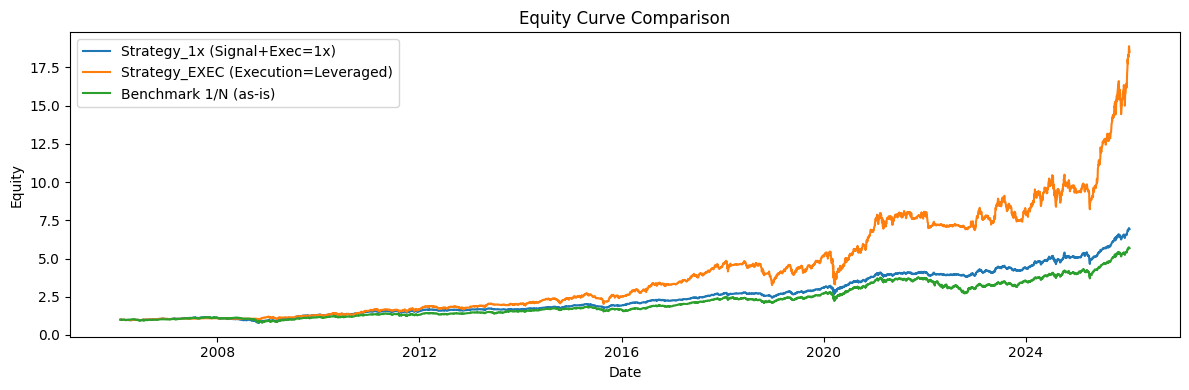

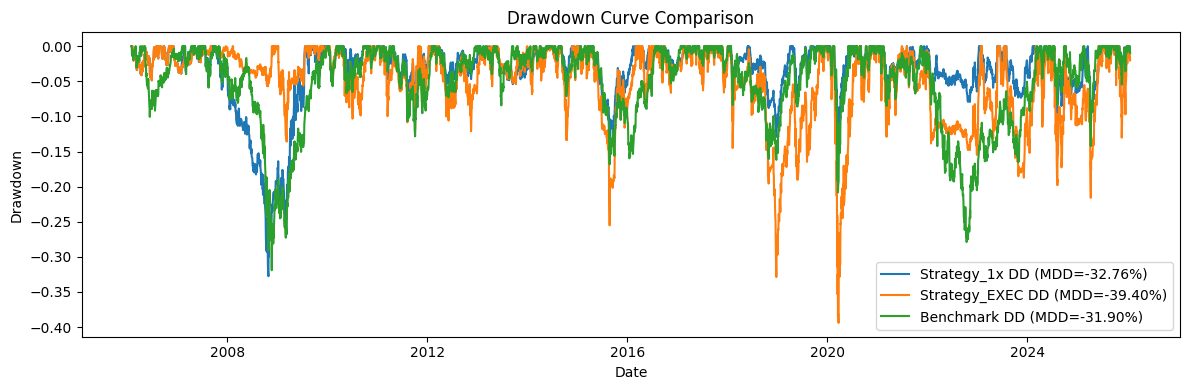

,CAGR,Vol,Sharpe,MDD
Strategy_1x,10.21%,11.10%,0.93,-32.76%
Strategy_EXEC(Leveraged),15.80%,18.70%,0.88,-39.40%
Benchmark_1/N,9.12%,13.53%,0.71,-31.90%


In [ ]:
# ============================================================
# [추가 셀] Signal(1x) 로직은 그대로 두고, 실제 투입(Execution)만 레버리지 ETF로 치환
#  - SPY  -> SPXL
#  - SOXX -> SOXL
#  - IEMG -> EDC
#  - EWY  -> KORU
#  - Benchmark(1/N) = 기존 bench_ret 그대로 유지
#  - 시각화: Equity / Drawdown / 요약표
# ============================================================

# 1) Execution 매핑
exec_map = {
    "SPY":  "SPXL",
    "SOXX": "SOXL",
    "IEMG": "EDC",
    "EWY":  "KORU",
}

# 2) 레버리지 ETF 가격 다운로드 및 수익률 생성
exec_tickers = sorted(set(exec_map.values()))
px_exec = download_close(exec_tickers, start, end)

# FutureWarning 방지: pct_change(fill_method=None)
ret_exec = px_exec.pct_change(fill_method=None).reindex(ret.index)

# 3) 기존 1배 ret을 복사하고, 해당 컬럼만 레버리지 수익률로 대체
ret_lev = ret.copy()
for base, lev in exec_map.items():
    if base in ret_lev.columns:
        if lev in ret_exec.columns:
            ret_lev[base] = ret_exec[lev]
        else:
            # 데이터 누락 시 0으로(안전) 처리
            ret_lev[base] = 0.0

# 남은 결측은 0으로(첫날/비거래일 등)
ret_lev = ret_lev.fillna(0.0)

# 4) "가중치(w_df/asof_w/turnover_s)"는 기존 그대로 사용, 수익률만 ret_lev로 계산
port_ret_lev = []
for dt in ret_lev.index:
    w_today = asof_w(dt)
    if w_today is None:
        continue

    r = ret_lev.loc[dt].fillna(0.0)
    pr = float((w_today.reindex(ret_lev.columns).fillna(0.0) * r).sum())

    # 리밸런싱 시점 거래비용 로직은 기존 그대로
    if dt in w_df.index:
        pr -= fee_per_turnover * float(turnover_s.get(dt, 0.0))

    port_ret_lev.append((dt, pr))

port_ret_lev = pd.Series(dict(port_ret_lev)).sort_index()
port_ret_lev.name = "Strategy_EXEC(Leveraged)"

# 5) 시각화 1) Equity Curve 비교 (기존 1x 전략 vs 레버리지 집행 vs 벤치마크)
eq_1x   = (1 + port_ret).cumprod()
eq_lev  = (1 + port_ret_lev).cumprod()
eq_bm   = (1 + bench_ret).cumprod()

plt.figure(figsize=(12,4))
plt.plot(eq_1x.index,  eq_1x.values,  label="Strategy_1x (Signal+Exec=1x)")
plt.plot(eq_lev.index, eq_lev.values, label="Strategy_EXEC (Execution=Leveraged)")
plt.plot(eq_bm.index,  eq_bm.values,  label="Benchmark 1/N (as-is)")
plt.title("Equity Curve Comparison")
plt.xlabel("Date"); plt.ylabel("Equity")
plt.legend()
plt.tight_layout()
plt.show()

# 6) 시각화 2) Drawdown 비교
def _drawdown_from_returns(daily_ret: pd.Series):
    eq = (1 + daily_ret.dropna()).cumprod()
    peak = eq.cummax()
    dd = eq / peak - 1.0
    return dd, float(dd.min())

dd_1x,  mdd_1x  = _drawdown_from_returns(port_ret)
dd_lev, mdd_lev = _drawdown_from_returns(port_ret_lev)
dd_bm,  mdd_bm  = _drawdown_from_returns(bench_ret)

plt.figure(figsize=(12,4))
plt.plot(dd_1x.index,  dd_1x.values,  label=f"Strategy_1x DD (MDD={mdd_1x:.2%})")
plt.plot(dd_lev.index, dd_lev.values, label=f"Strategy_EXEC DD (MDD={mdd_lev:.2%})")
plt.plot(dd_bm.index,  dd_bm.values,  label=f"Benchmark DD (MDD={mdd_bm:.2%})")
plt.title("Drawdown Curve Comparison")
plt.xlabel("Date"); plt.ylabel("Drawdown")
plt.legend()
plt.tight_layout()
plt.show()

# 7) 성과 요약표
def _perf_summary(daily_ret: pd.Series, ann=252):
    daily_ret = daily_ret.dropna()
    eq = (1 + daily_ret).cumprod()
    cagr = eq.iloc[-1] ** (ann / max(len(daily_ret), 1)) - 1
    vol = daily_ret.std() * np.sqrt(ann)
    sharpe = (daily_ret.mean() / (daily_ret.std() + 1e-12)) * np.sqrt(ann)
    peak = eq.cummax()
    mdd = (eq / peak - 1).min()
    return pd.Series({"CAGR": cagr, "Vol": vol, "Sharpe": sharpe, "MDD": mdd})

summary = pd.concat(
    [
        _perf_summary(port_ret).rename("Strategy_1x"),
        _perf_summary(port_ret_lev).rename("Strategy_EXEC(Leveraged)"),
        _perf_summary(bench_ret).rename("Benchmark_1/N"),
    ],
    axis=1
).T

display(summary.style.format({"CAGR":"{:.2%}","Vol":"{:.2%}","Sharpe":"{:.2f}","MDD":"{:.2%}"}))

In [ ]:
w_df_exec = w_df.copy()
w_df_exec = w_df_exec.rename(columns=exec_map)
display(w_df_exec.tail(12).round(4))
latest_weights_exec = w_df_exec.iloc[-1]
latest_weights_exec = latest_weights_exec[latest_weights_exec > 0]
final_portfolio_exec = latest_weights_exec.reset_index()
final_portfolio_exec.columns = ['code', 'weight']
final_portfolio_exec.to_csv('target_portfolio.csv', index=False)

print("\n" + "="*50)
print(f"최신 리밸런싱 날짜: {w_df_exec.index[-1].date()}")
print("레버리지 실행 포트폴리오가 'target_portfolio.csv'로 저장되었습니다.")
print("-" * 50)
print(final_portfolio_exec.to_string(index=False))
print("="*50)

Ticker,BND,CQQQ,KORU,GLD,EDC,SMH,SOXL,SPXL,TLT,UUP,VWO
RebalanceDate,,,,,,,,,,,
2024-09-30,0.0,0.2805,0.0000,0.1071,0.0761,0.0529,0.0298,0.0608,0.1186,0.2743,0.0
2024-10-31,0.0,0.0402,0.0796,0.1112,0.1161,0.0566,0.0555,0.1521,0.1230,0.2658,0.0
2024-12-31,0.0,0.0000,0.0000,0.2232,0.0000,0.0000,0.0000,0.0000,0.2464,0.5304,0.0
2025-01-31,0.0,0.2550,0.0000,0.1157,0.0304,0.0089,0.0000,0.2057,0.1355,0.2489,0.0
2025-02-28,0.0,0.4466,0.0000,0.1226,0.0328,0.0000,0.0000,0.0206,0.1290,0.2484,0.0
2025-03-31,0.0,0.4060,0.0000,0.1318,0.0940,0.0000,0.0000,0.0000,0.1359,0.2323,0.0
2025-04-30,0.0,0.0000,0.3373,0.1146,0.1627,0.0000,0.0000,0.0000,0.1443,0.2411,0.0
2025-06-30,0.0,0.0413,0.1407,0.0974,0.0574,0.1139,0.1021,0.0446,0.1577,0.2449,0.0
2025-07-31,0.0,0.0898,0.1037,0.0960,0.0493,0.1252,0.0782,0.0538,0.1590,0.2450,0.0



최신 리밸런싱 날짜: 2025-12-31
레버리지 실행 포트폴리오가 'target_portfolio.csv'로 저장되었습니다.
--------------------------------------------------
code   weight
CQQQ 0.021229
KORU 0.215923
 GLD 0.052776
 EDC 0.054570
 SMH 0.095096
SOXL 0.082505
SPXL 0.030678
 TLT 0.158583
 UUP 0.288641
